# Detecting Earthquake Precursors in the Ionosphere using Wavelets

Workflow:
1. Choosing Earthquakes.
2. Downloading IONEX data.
3. Converting IONEX to NetCDF.
4. Processing dataset.
5. Wavelet Analysis.

## 1. Choosing Earthquakes.

I used GEOFON to select 10 earthquakes of magnitude 6 or greater, starting from 2017 to 2025, ensuring that the selected quakes provide a representative coverage of the Philippines. I've named the earthquakes for convenience based on the province of or nearest to their epicenter.

| Names | Mw | ° N | ° E | Depth (km) | YYYY-MM-DD | hh:mm:ss (UTC) |
| --- | --- | --- | --- | --- | --- | --- |
| DavOcc_EQ	| 6.8	| 5.56	| 124.78	| 31	| 2017-04-28	| 22:23:17 |
| DavOr_EQ	| 6.89	| 5.9	| 126.64	| 69	| 2018-12-29	| 3:39:11 |
| NorCot_EQ	| 6.5	| 6.8	| 125.12	| 10	| 2019-10-29	| 1:04:43 |
| Masbate_EQ	| 6.57	| 11.99	| 124.04	| 10	| 2020-08-18	| 0:03:49 |
| Batangas_EQ	| 6.58	| 13.66	| 120.74	| 131	| 2021-07-23	| 20:48:59 |
| Abra_EQ	| 6.99	| 17.5	| 120.82	| 21	| 2022-07-27	| 0:43:25 |
| SurdelSur_EQ	| 7.48	| 8.59	| 126.39	| 40	| 2023-12-02	| 14:37:05 |
| Basilan_EQ	| 7.04	| 6.1	| 123.15	| 639	| 2024-07-11	| 2:13:18 |
| Cebu_EQ	| 6.82	| 11.12	| 124.13	| 15	| 2025-09-30	| 13:59:45 |
| Davao_EQ	| 7.39	| 7.34	| 126.69	| 48	| 2025-10-10	| 1:43:58 |

In [13]:
# 1. Declaring Array Of (Lat, Lon, Name, Date) Per Earthquake

import numpy as np

EQs = np.array([[5.56,124.78, "DavOcc_EQ", "2017-04-28", 6.80, 31],
                [5.9,126.64, "DavOr_EQ", "2018-12-29", 6.89, 69],
                [6.8,125.12, "NorCot_EQ", "2019-10-29", 6.50, 10],
                [11.99,124.04, "Masbate_EQ", "2020-08-18", 6.57, 10],
                [13.66,120.74, "Batangas_EQ", "2021-07-23", 6.58, 131],
                [17.5,120.82, "Abra_EQ", "2022-07-27", 6.99, 21],
                [8.59,126.39, "SurdelSur_EQ", "2023-12-02", 7.48, 40],
                [6.1,123.15, "Basilan_EQ", "2024-07-11", 7.04, 639],
                [11.12,124.13, "Cebu_EQ", "2025-09-30", 6.82, 15],
                [7.34,126.69, "Davao_EQ", "2025-10-10", 7.39, 48]])

## 2. Downloading IONEX data.

I used the IONEX downloader **spinifex**, a Python package dedicated to reading IONEX data from various providers. Since NASA's Crustal Dynamics Data Information System data causes persistent authentication issues, I decided to use instead IGS Ionosphere Working Group server's data. Note that the file naming convention switches in 2022.

## 3. Converting IONEX to NetCDF.

## 4. Processing dataset.

In [13]:
%%bash

# Just Checking

cdo sinfo combined_tec_17-25.nc
ncdump -h combined_tec_17-25.nc

   File format : NetCDF4
    -1 : Institut Source   T Steptype Levels Num    Points Num Dtype : Parameter ID
     1 : unknown  unknown  v instant       1   1      5183   1  F64  : -1            
   Grid coordinates :
     1 : lonlat                   : points=5183 (73x71)
                              lon : -180 to 180 by 5 degrees_east
                              lat : -87.5 to 87.5 by 2.5 degrees_north
   Vertical coordinates :
     1 : surface                  : levels=1
   Time coordinate :
                             time : 38491 steps
     RefTime =  2017-01-01 00:00:00  Units = hours  Calendar = proleptic_gregorian
  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss
  2017-01-01 00:00:00  2017-01-01 02:00:00  2017-01-01 04:00:00  2017-01-01 06:00:00
  2017-01-01 08:00:00  2017-01-01 10:00:00  2017-01-01 12:00:00  2017-01-01 14:00:00
  2017-01-01 16:00:00  2017-01-01 18:00:00  2017-01-01 20:00:00  2017-01-01 22:00:00
  2017-01-02 00:00:00  2017

In [14]:
%%bash

# 1. Cutting Out Area of Interest

# lon1, lon2, lat1, lat2
philippines="115,135,0,25"

region=$philippines
region_tag=_area$(echo $region | tr , _) 

ifile=combined_tec_17-25.nc #declaring input file per year
ofile=pinas_tec_17-25.nc #declaring output file per year
cdo -s -O sellonlatbox,${region} $ifile $ofile #sellecting data within the longitude latitude box

In [5]:
%%bash

# 2. Cutting 2 Months Before And After Each Earthquake

nam=pinas_tec_

cdo -O seldate,2017-02-28,2017-06-28 ${nam}17-25.nc DavOcc_EQ_2mo.nc
cdo -O seldate,2018-10-29,2019-02-29 ${nam}17-25.nc DavOr_EQ_2mo.nc
cdo -O seldate,2019-08-29,2019-12-29 ${nam}17-25.nc NorCot_EQ_2mo.nc
cdo -O seldate,2020-06-18,2020-10-18 ${nam}17-25.nc Masbate_EQ_2mo.nc
cdo -O seldate,2021-05-23,2021-09-23 ${nam}17-25.nc Batangas_EQ_2mo.nc
cdo -O seldate,2022-05-27,2022-09-27 ${nam}17-25.nc Abra_EQ_2mo.nc
cdo -O seldate,2023-10-02,2024-02-02 ${nam}17-25.nc SurdelSur_EQ_2mo.nc
cdo -O seldate,2024-05-11,2024-09-11 ${nam}17-25.nc Basilan_EQ_2mo.nc
cdo -O seldate,2025-07-30,2025-11-30 ${nam}17-25.nc Cebu_EQ_2mo.nc
cdo -O seldate,2025-08-10,2025-12-10 ${nam}17-25.nc Davao_EQ_2mo.nc

In [6]:
%%bash

# 3. Compute Amomalies Per Earthquake

EQs=(
  "DavOcc_EQ"
  "DavOr_EQ"
  "NorCot_EQ"
  "Masbate_EQ"
  "Batangas_EQ"
  "Abra_EQ"
  "SurdelSur_EQ"
  "Basilan_EQ"
  "Cebu_EQ"
  "Davao_EQ"
)

for eq in "${EQs[@]}"; do
    infile="${eq}_2mo.nc"
    meanfile="${eq}_2mo_timmean.nc"
    anomfile="${eq}_2mo_anom.nc"

    cdo -s -O timmean "$infile" "$meanfile"
    cdo -s -O sub "$infile" "$meanfile" "$anomfile"

    echo "Created: $anomfile"
done

Created: DavOcc_EQ_2mo_anom.nc
Created: DavOr_EQ_2mo_anom.nc
Created: NorCot_EQ_2mo_anom.nc
Created: Masbate_EQ_2mo_anom.nc
Created: Batangas_EQ_2mo_anom.nc
Created: Abra_EQ_2mo_anom.nc
Created: SurdelSur_EQ_2mo_anom.nc
Created: Basilan_EQ_2mo_anom.nc
Created: Cebu_EQ_2mo_anom.nc
Created: Davao_EQ_2mo_anom.nc


In [7]:
# 4. Creating Timeseries

import xarray as xr

for i in range(10):
    print(EQs[i,2]+"_2mo_anom.nc")
    ds = xr.open_dataset(EQs[i,2]+"_2mo_anom.nc")
    
    # select nearest grid point
    point = ds.sel(
        lat=EQs[i,0],
        lon=EQs[i,1],
        method="nearest"
    )

    df = point["tec"].to_dataframe().reset_index()
    df = df.drop(columns=["lat", "lon"])
    df.to_csv(f"{EQs[i,2]}_point_2mo_anom.csv", index=False) #saves as a TEC timeseries
    print("Created "+str(EQs[i,2])+"_point_2mo_anom.csv")

    ds = xr.open_dataset(EQs[i,2]+"_2mo.nc")
    
    # select nearest grid point
    point = ds.sel(
        lat=EQs[i,0],
        lon=EQs[i,1],
        method="nearest"
    )

    df = point["tec"].to_dataframe().reset_index()
    df = df.drop(columns=["lat", "lon"])
    df.to_csv(f"{EQs[i,2]}_point_2mo.csv", index=False) #saves as a TEC timeseries
    print("Created "+str(EQs[i,2])+"_point_2mo.csv")

DavOcc_EQ_2mo_anom.nc
Created DavOcc_EQ_point_2mo_anom.csv
Created DavOcc_EQ_point_2mo.csv
DavOr_EQ_2mo_anom.nc
Created DavOr_EQ_point_2mo_anom.csv
Created DavOr_EQ_point_2mo.csv
NorCot_EQ_2mo_anom.nc
Created NorCot_EQ_point_2mo_anom.csv
Created NorCot_EQ_point_2mo.csv
Masbate_EQ_2mo_anom.nc
Created Masbate_EQ_point_2mo_anom.csv
Created Masbate_EQ_point_2mo.csv
Batangas_EQ_2mo_anom.nc
Created Batangas_EQ_point_2mo_anom.csv
Created Batangas_EQ_point_2mo.csv
Abra_EQ_2mo_anom.nc
Created Abra_EQ_point_2mo_anom.csv
Created Abra_EQ_point_2mo.csv
SurdelSur_EQ_2mo_anom.nc
Created SurdelSur_EQ_point_2mo_anom.csv
Created SurdelSur_EQ_point_2mo.csv
Basilan_EQ_2mo_anom.nc
Created Basilan_EQ_point_2mo_anom.csv
Created Basilan_EQ_point_2mo.csv
Cebu_EQ_2mo_anom.nc
Created Cebu_EQ_point_2mo_anom.csv
Created Cebu_EQ_point_2mo.csv
Davao_EQ_2mo_anom.nc
Created Davao_EQ_point_2mo_anom.csv
Created Davao_EQ_point_2mo.csv


## 5. Wavelet Analysis.

In [8]:
# 2. Using The Tompkins Manual Method

import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd


# Define the Full Morlet Wavelet
def morlet_wavelet(t, w0=6.0):
    """Generates a complex Morlet wavelet."""
    return np.pi**(-0.25) * np.exp(1j * w0 * t) * np.exp(-0.5 * t**2)

# but first I will show the components.
def morlet_components(eta, w0=6.0):
    # Part 1: The Normalization Constant
    norm = np.pi**(-0.25)
    
    # Part 2: The Gaussian Envelope (The "let" in Wavelet)
    envelope = np.exp(-0.5 * eta**2)
    
    # Part 3: The Complex Oscillator (The "Wave" in Wavelet)
    # e^(i*w0*eta) = cos(w0*eta) + i*sin(w0*eta)
    real_oscillation = np.cos(w0 * eta)
    imag_oscillation = np.sin(w0 * eta)
    
    # The Full Result
    full_wavelet = norm * envelope * (real_oscillation + 1j * imag_oscillation)
    
    return norm * envelope, real_oscillation, imag_oscillation, full_wavelet

In [9]:
def cwt_scratch(data, dt, scales, w0=6.0):
    n_signal = len(data)
    cwt_matrix = np.zeros((len(scales), n_signal), dtype=complex)
    
    for i, s in enumerate(scales):
        
        # 1. Create wavelet time vector
        
        # this is the width in standard deviations:
        # a half width of 3*s cutting the wavelet off while it 
        # still has 1% of its power. 
        # This creates "edge effects" or "ringing" in your transform 
        # because you've abruptly chopped off the ends of the wave.
        # at 8*s we have $e^{-0.5(8^2)} = 
        # e^{-32} \approx 1.2 \times 10^{-14}$ amplitude
        half_width = 8 * s
        n_samples = int(2 * half_width / dt)
        
        # ensure we have central pt by making the len odd.
        if n_samples % 2 == 0: n_samples += 1 
        t_wavelet = np.linspace(-half_width, half_width, n_samples)
        
        # Generate wavelet using our earlier routine, yay!
        wavelet = morlet_wavelet(t_wavelet/s, w0) 

        # Perform convolution, let's use numpy for this as we already saw this earlier 
        # but if you want you can use the dot product we introduced in the DFT lecture
        # if you really really want to :-) 
        full_conv = np.convolve(data, np.conj(wavelet), mode='full') * (np.sqrt(dt/s))
        
        # Manually slice the center to match n_signal
        # 
        start = (len(wavelet) - 1) // 2
        end = start + n_signal
        cwt_matrix[i, :] = full_conv[start:end]
        
    return cwt_matrix

In [10]:
import matplotlib.dates as mdates

def plot_wavelet_spectrum(time, periods, power, title="Wavelet Power Spectrum", 
                          v_signal=None, ylabel="Period (Days)",tstitle="Signal Amplitude"):
    """
    Plots a professional scalogram for atmospheric signals.
    Returns: (fig, ax_signal, ax_wavelet)
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [1, 2]})

    # Top Panel: Time Series
    if v_signal is not None:
        ax1.plot(time, v_signal, color='black', lw=0.8)
        ax1.set_ylabel(tstitle)
        ax1.set_title('Time Series of Signal')
    ax1.grid(alpha=0.3)
    
    # Safely calculate variance normalization and log if v_signal is provided
    if v_signal is not None:
        variance = np.var(v_signal)
        norm_power = power / variance
    else:
        norm_power = power
        
    log_power = np.log(norm_power + 1e-8)
    
    # Dynamically find the real ceiling of your data
    actual_max = np.nanmax(log_power)
    
    # Set the floor to the 50th percentile to hide background static
    # (Adjust this number up if it's still too noisy, down if it's too dark)
    actual_min = np.nanpercentile(log_power, 50) 
    
    # Bottom Panel: The Scalogram
    pcm = ax2.pcolormesh(time, periods, log_power, 
                         shading='auto', 
                         vmin=actual_min,  # dynamically set!
                         vmax=actual_max,  # dynamically set! 
                         cmap='magma')

    # Standard atmospheric science log-y setup
    ax2.set_yscale('log')
    # Custom ticks for diurnal and AEW ranges
    ytick_values = [0.5, 1, 2, 3, 4, 5, 7, 10, 15, 30]
    ax2.set_yticks([t for t in ytick_values if t >= periods.min() and t <= periods.max()])
    ax2.get_yaxis().set_major_formatter(plt.ScalarFormatter())
    
    # Utilizing your custom ylabel argument
    ax2.set_ylabel(ylabel)
    ax2.set_title(title)

    # Format X-Axis
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    # Colorbar
    fig.colorbar(pcm, ax=ax2, orientation='horizontal', pad=0.15, label='log(Normalized Power/Variance)')

    return fig, ax1, ax2

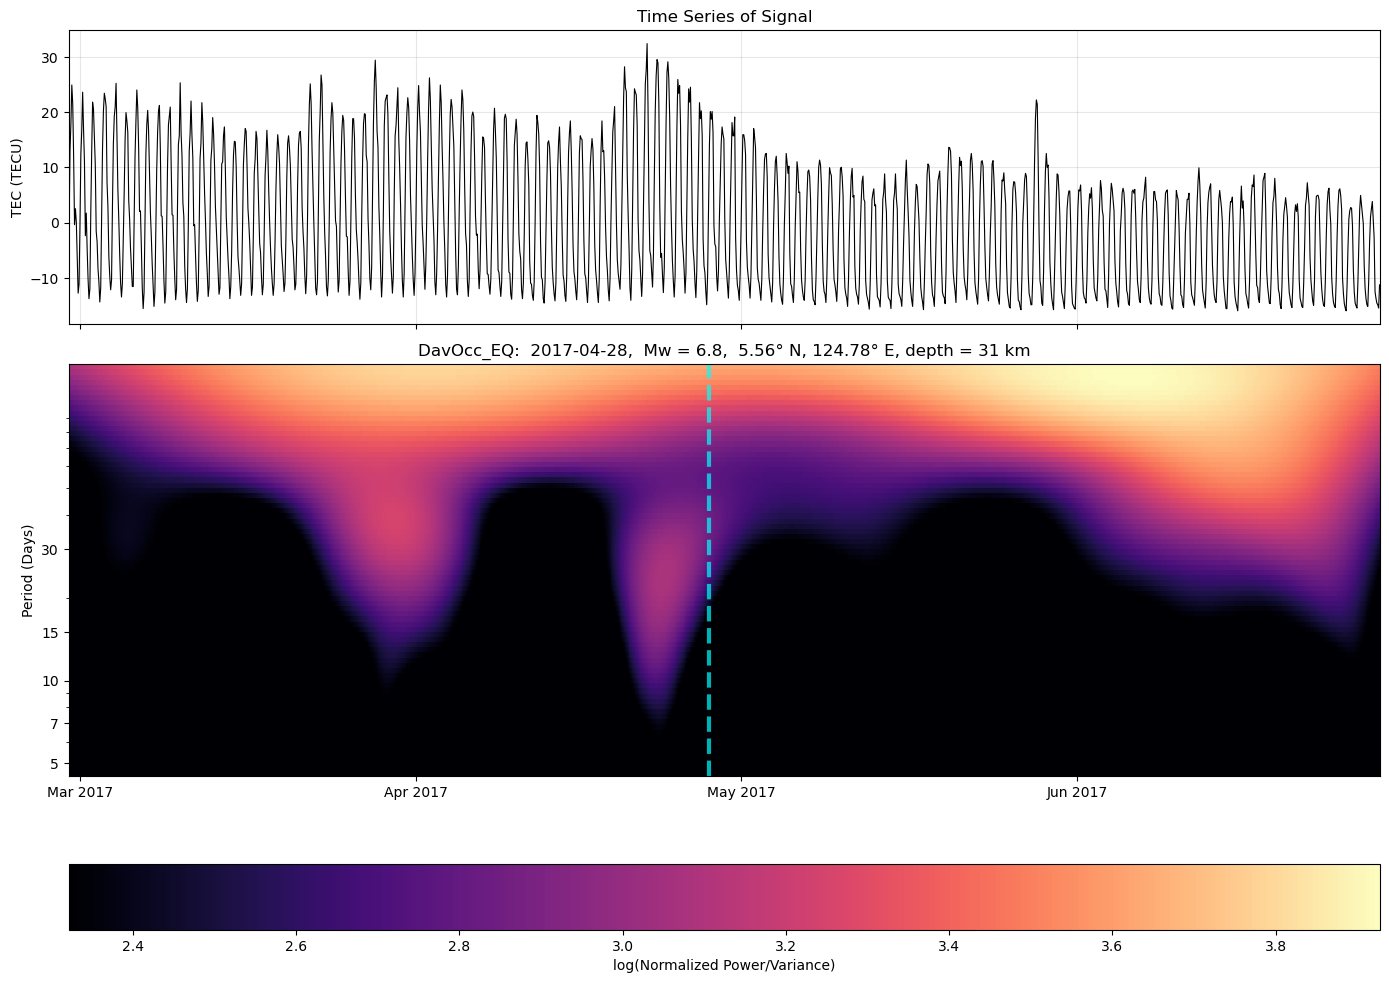

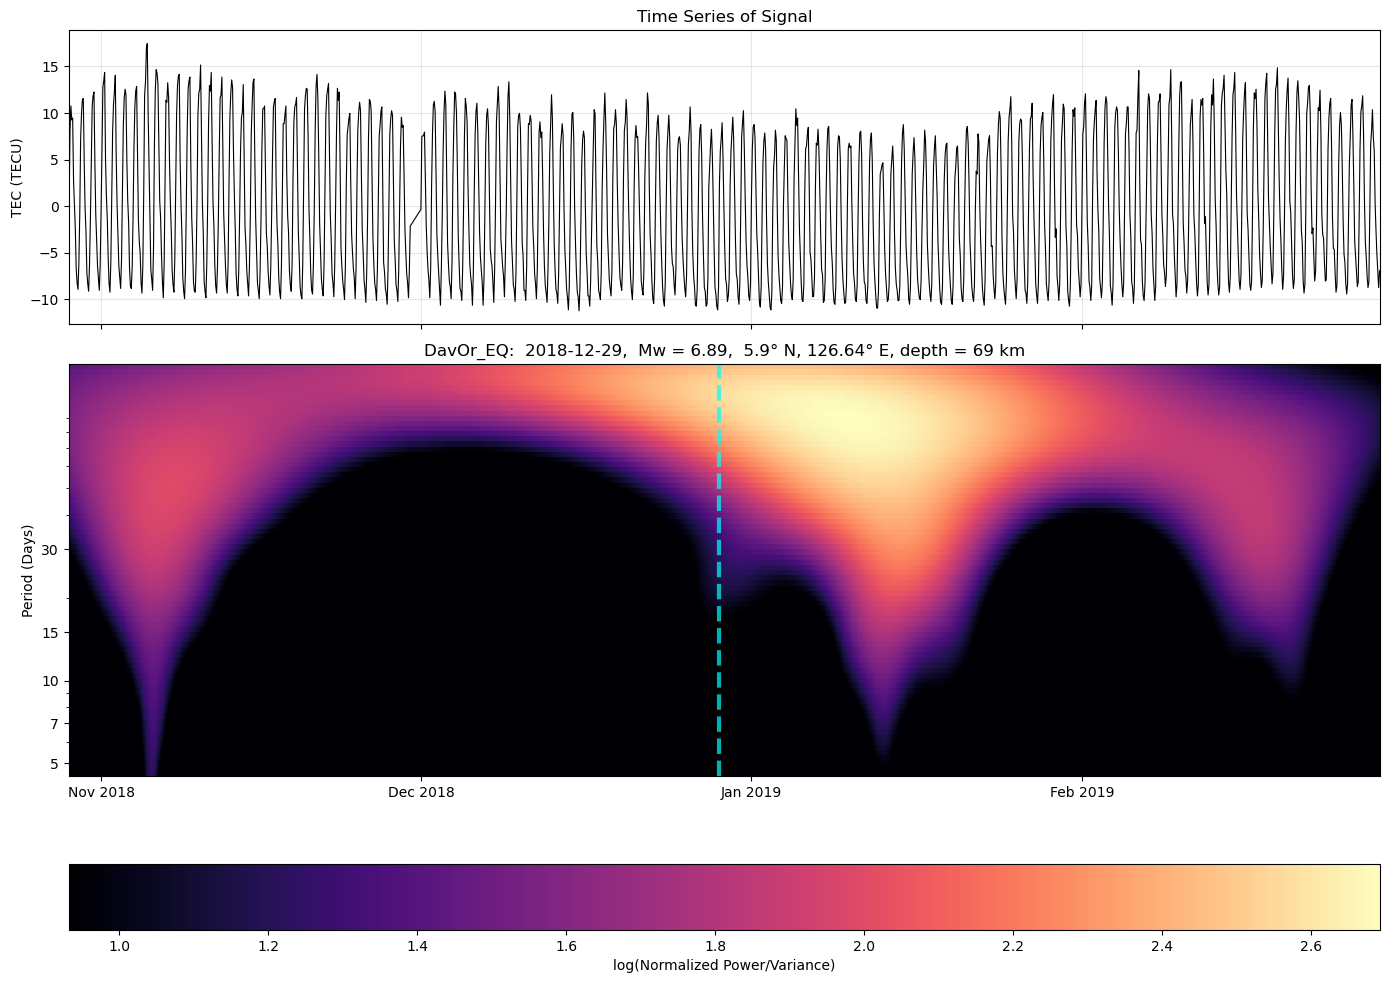

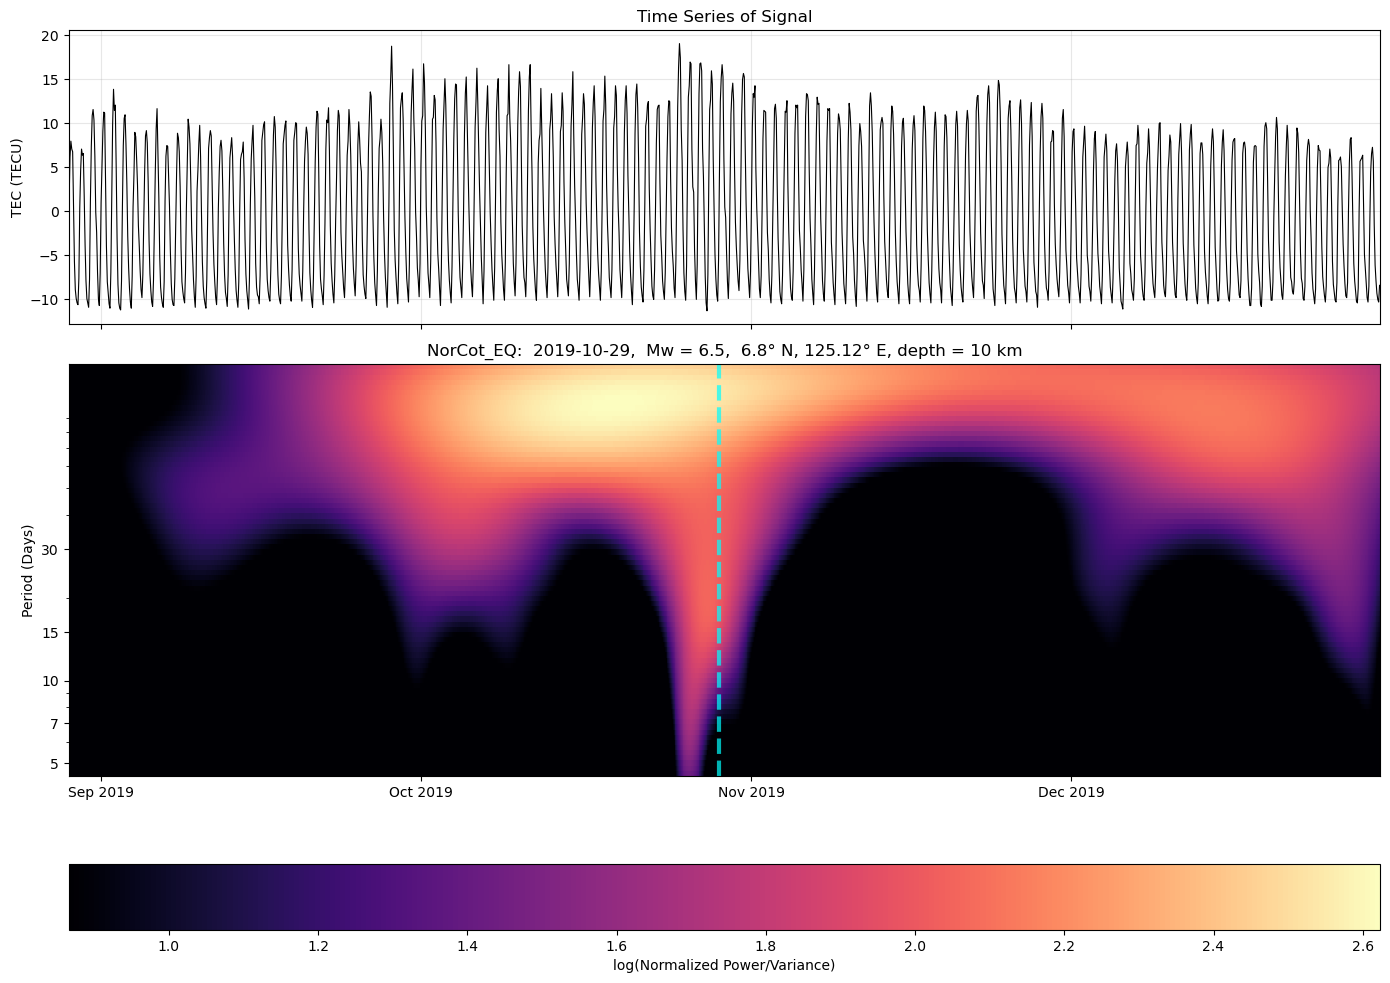

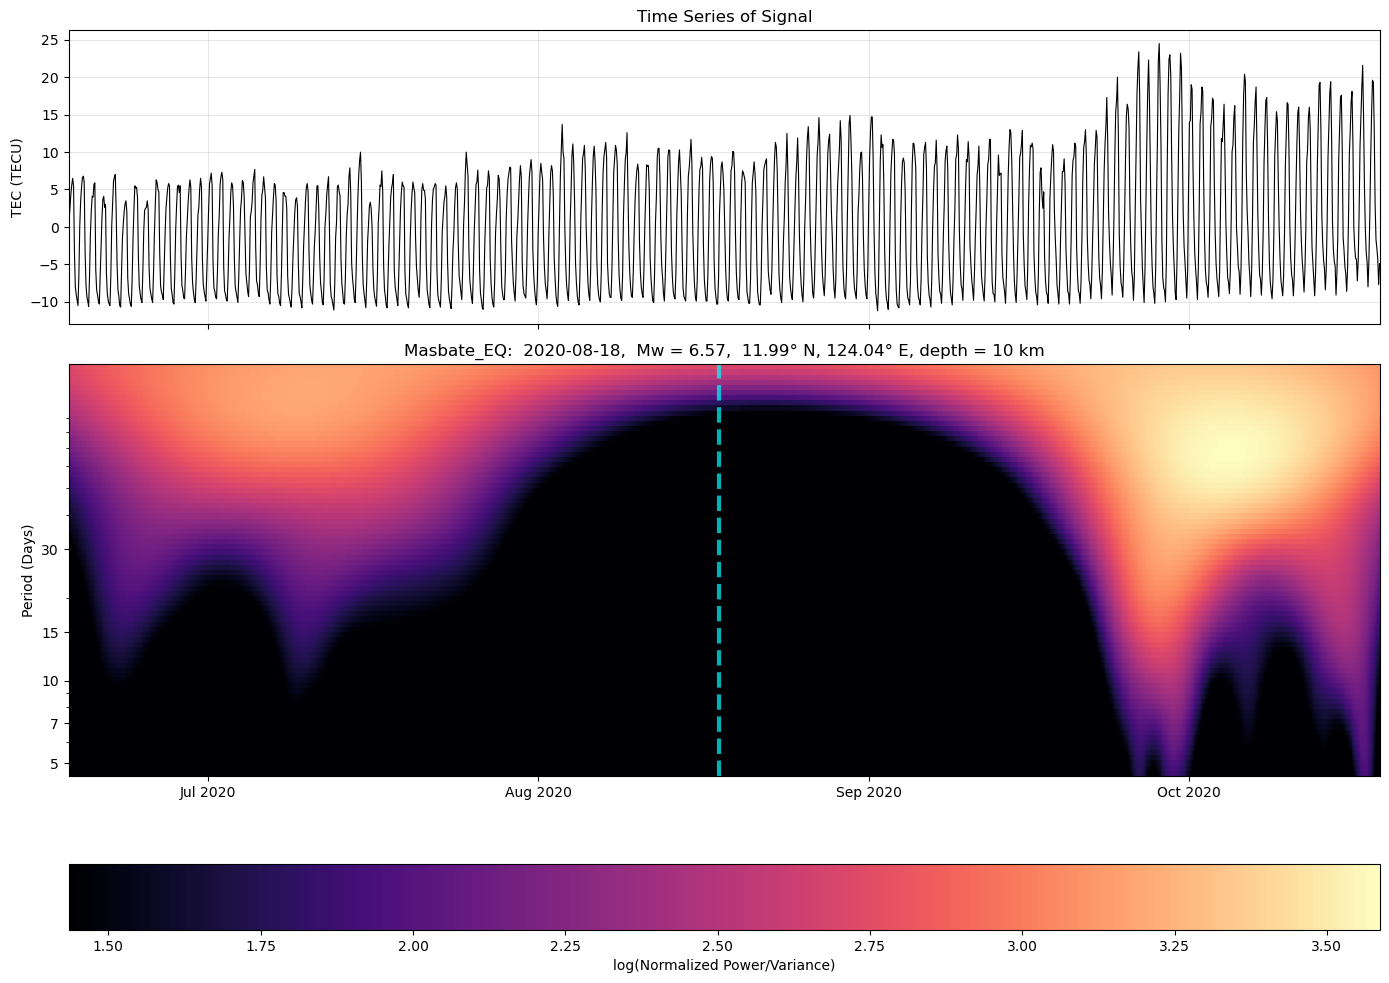

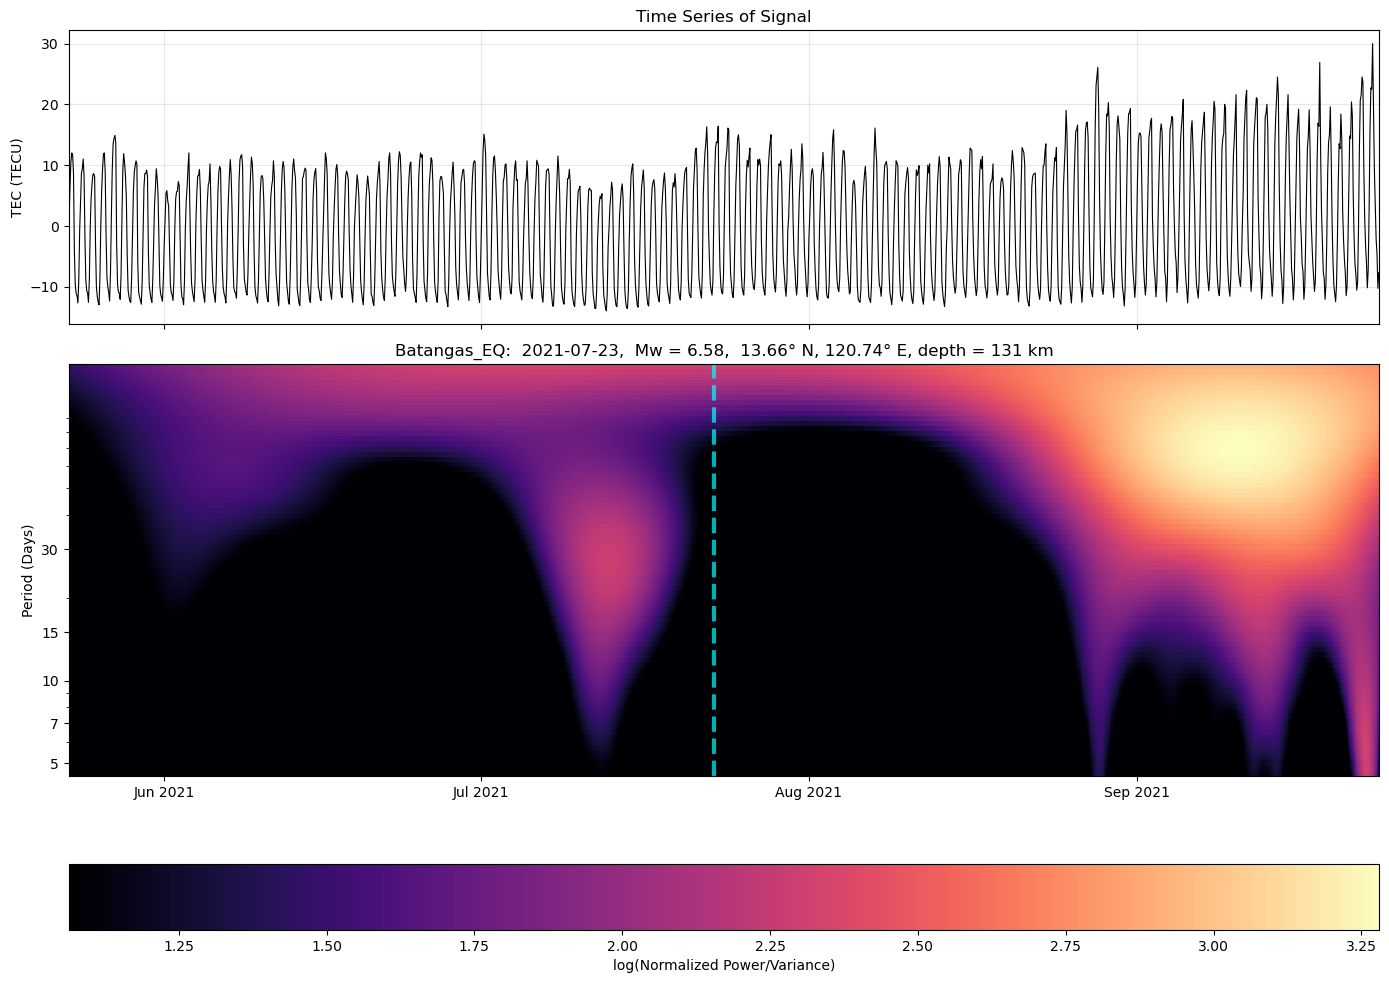

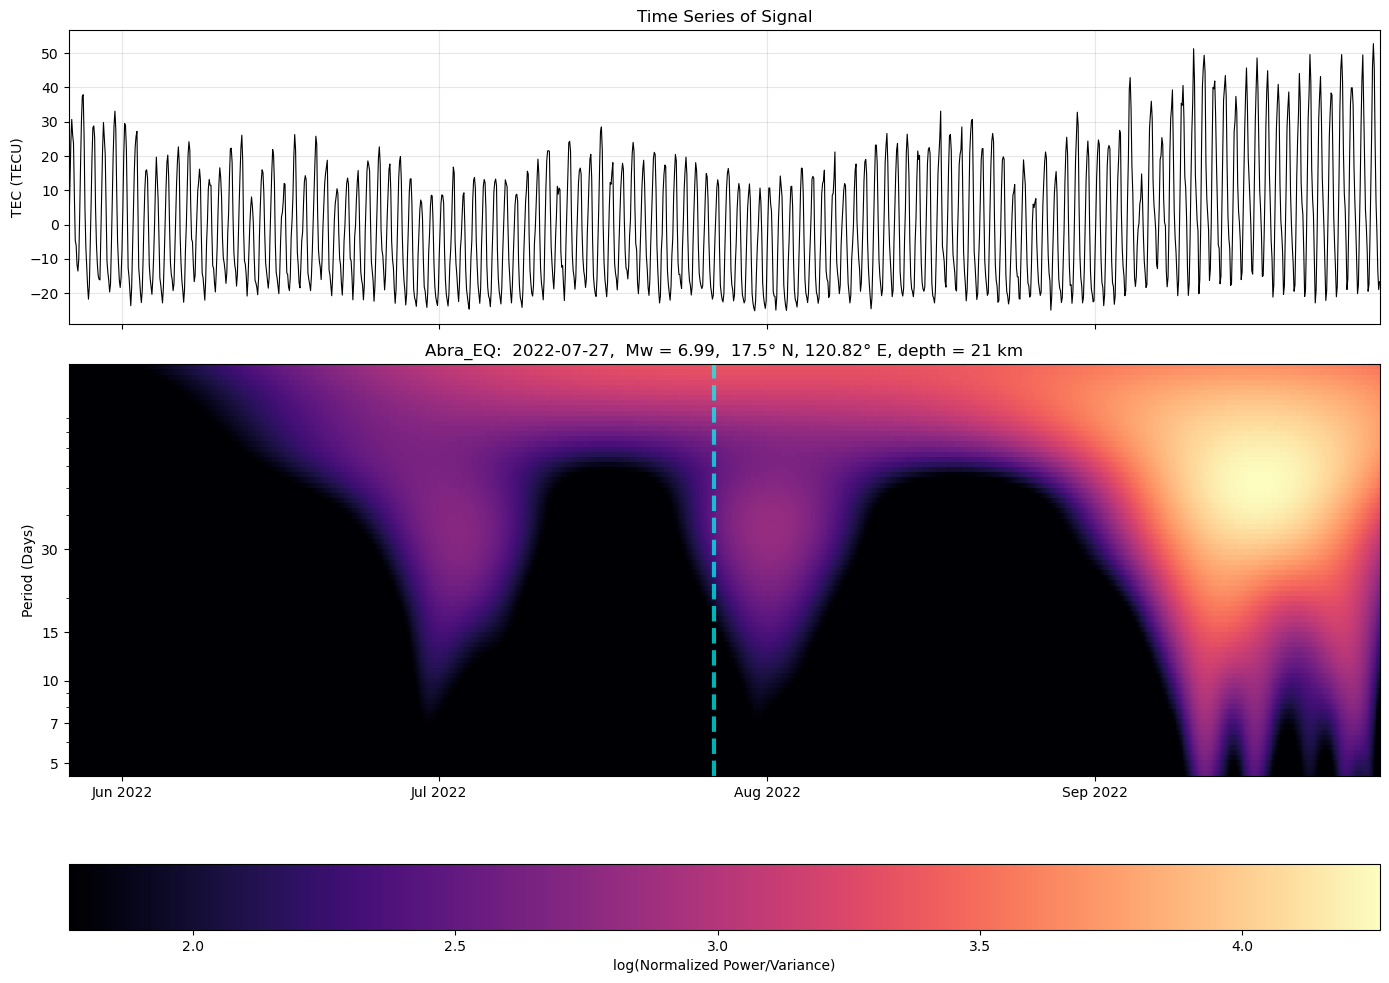

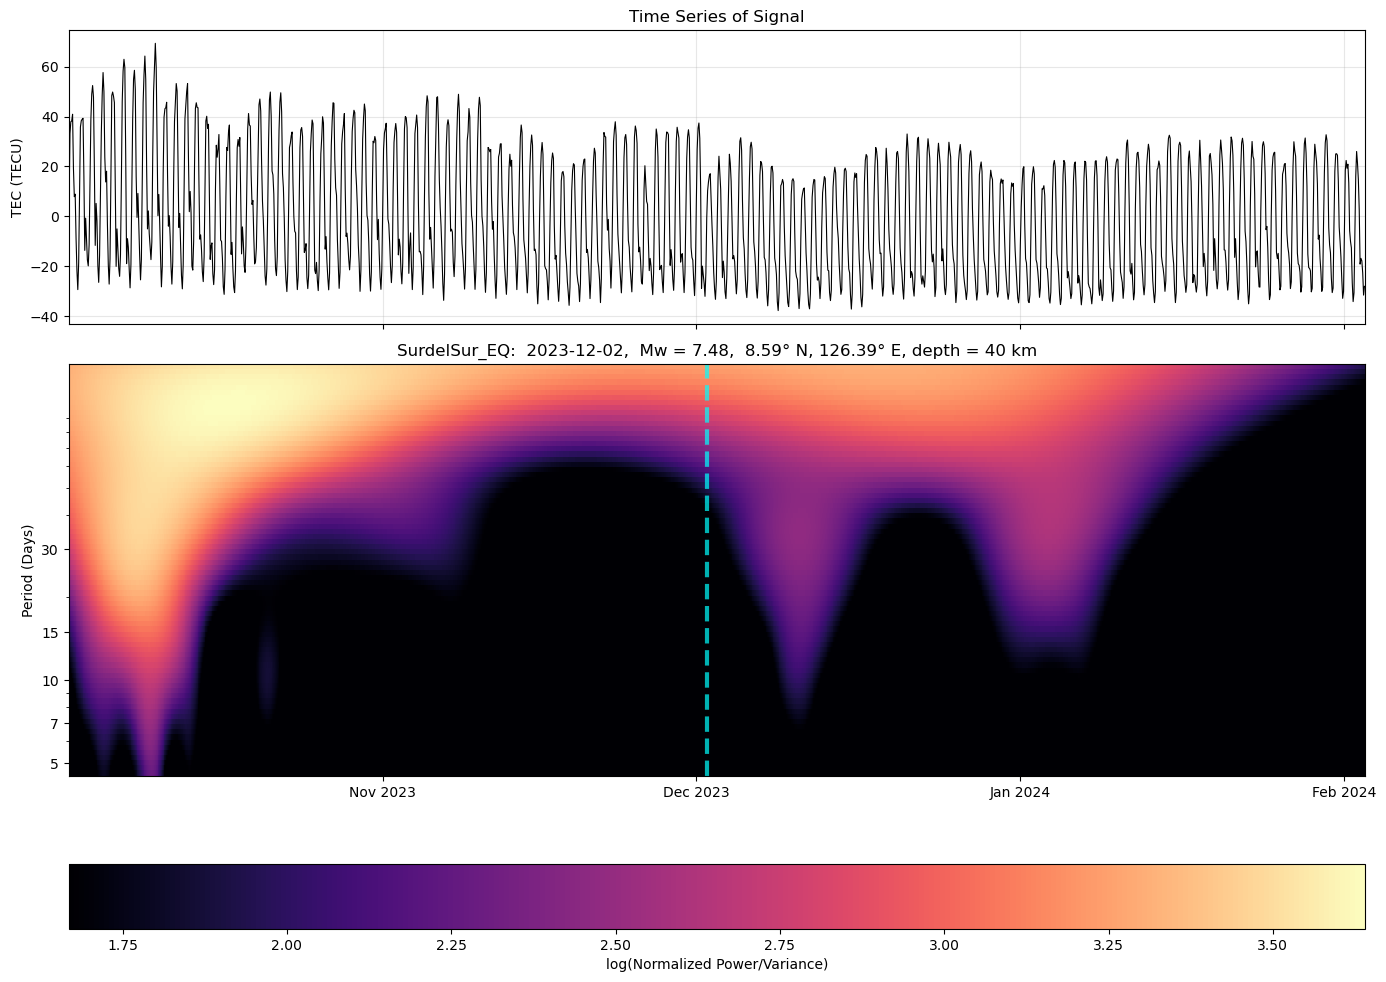

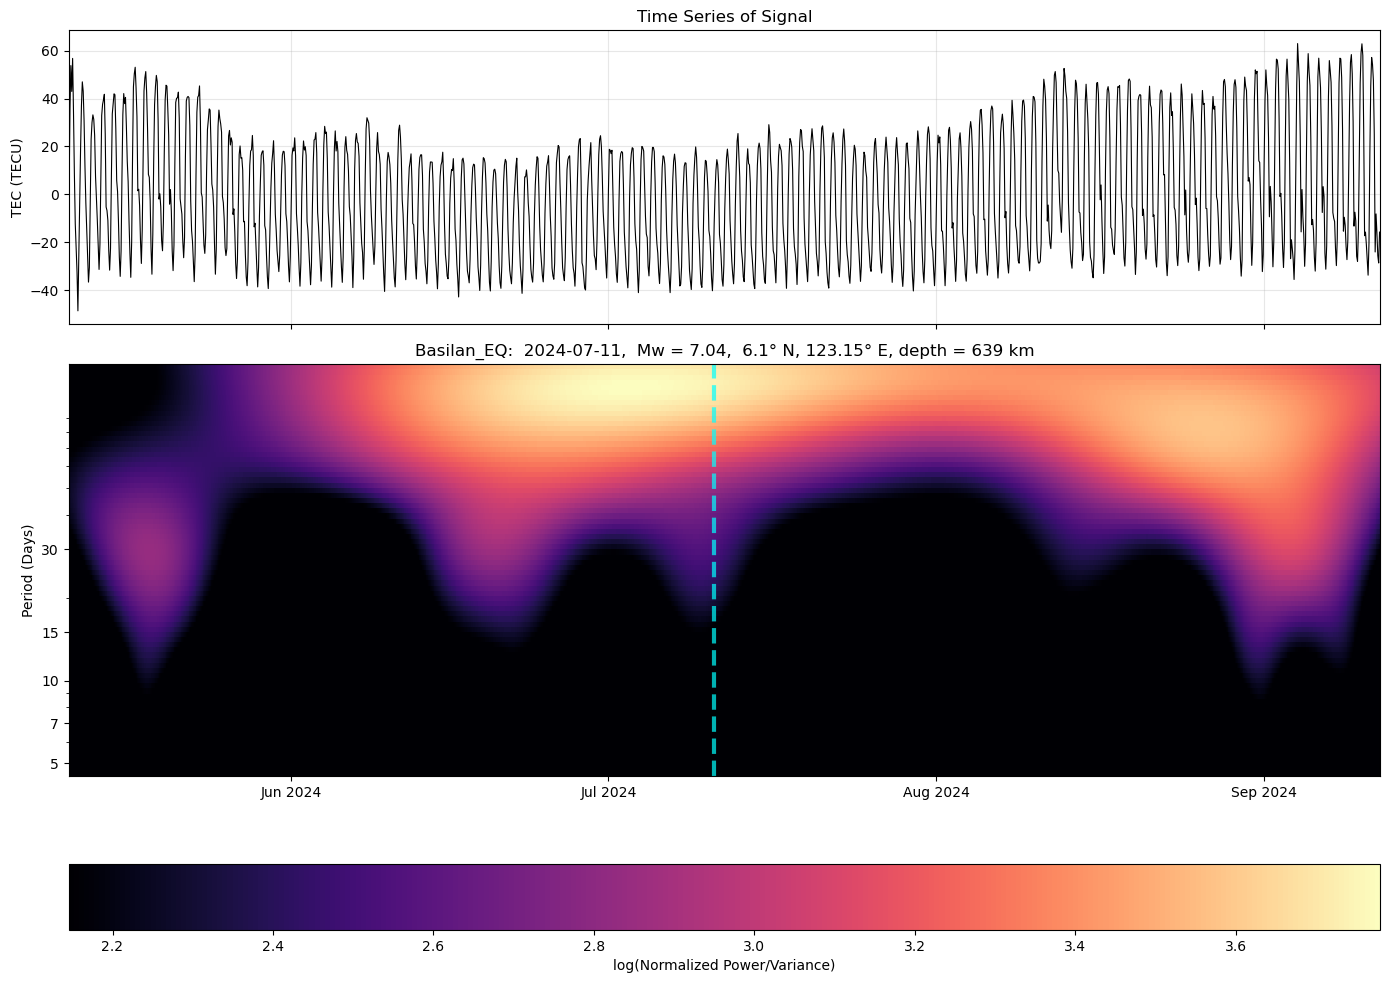

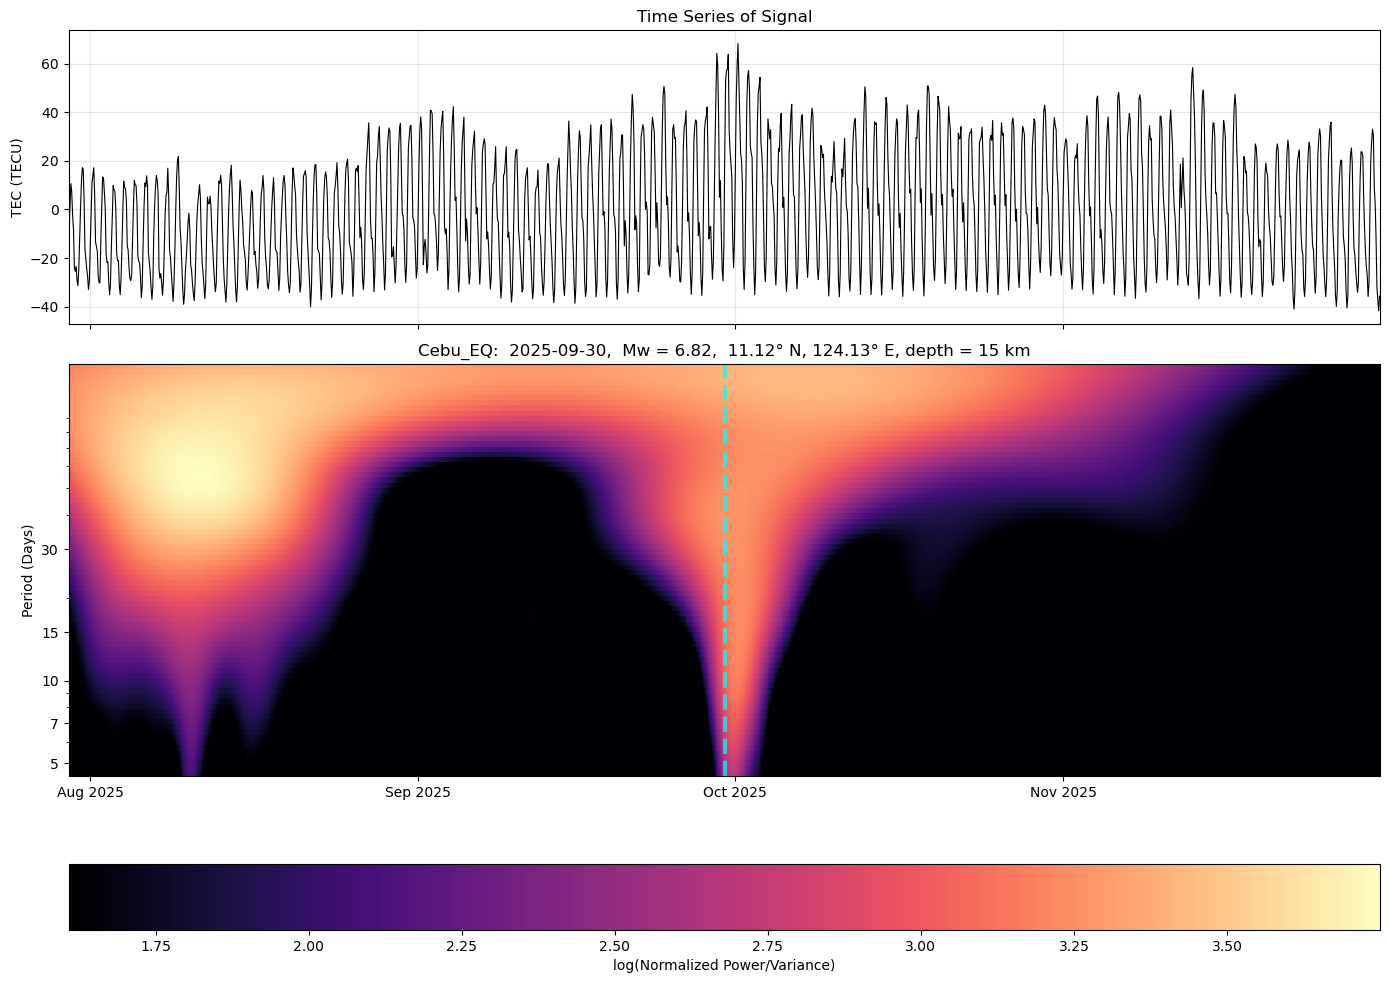

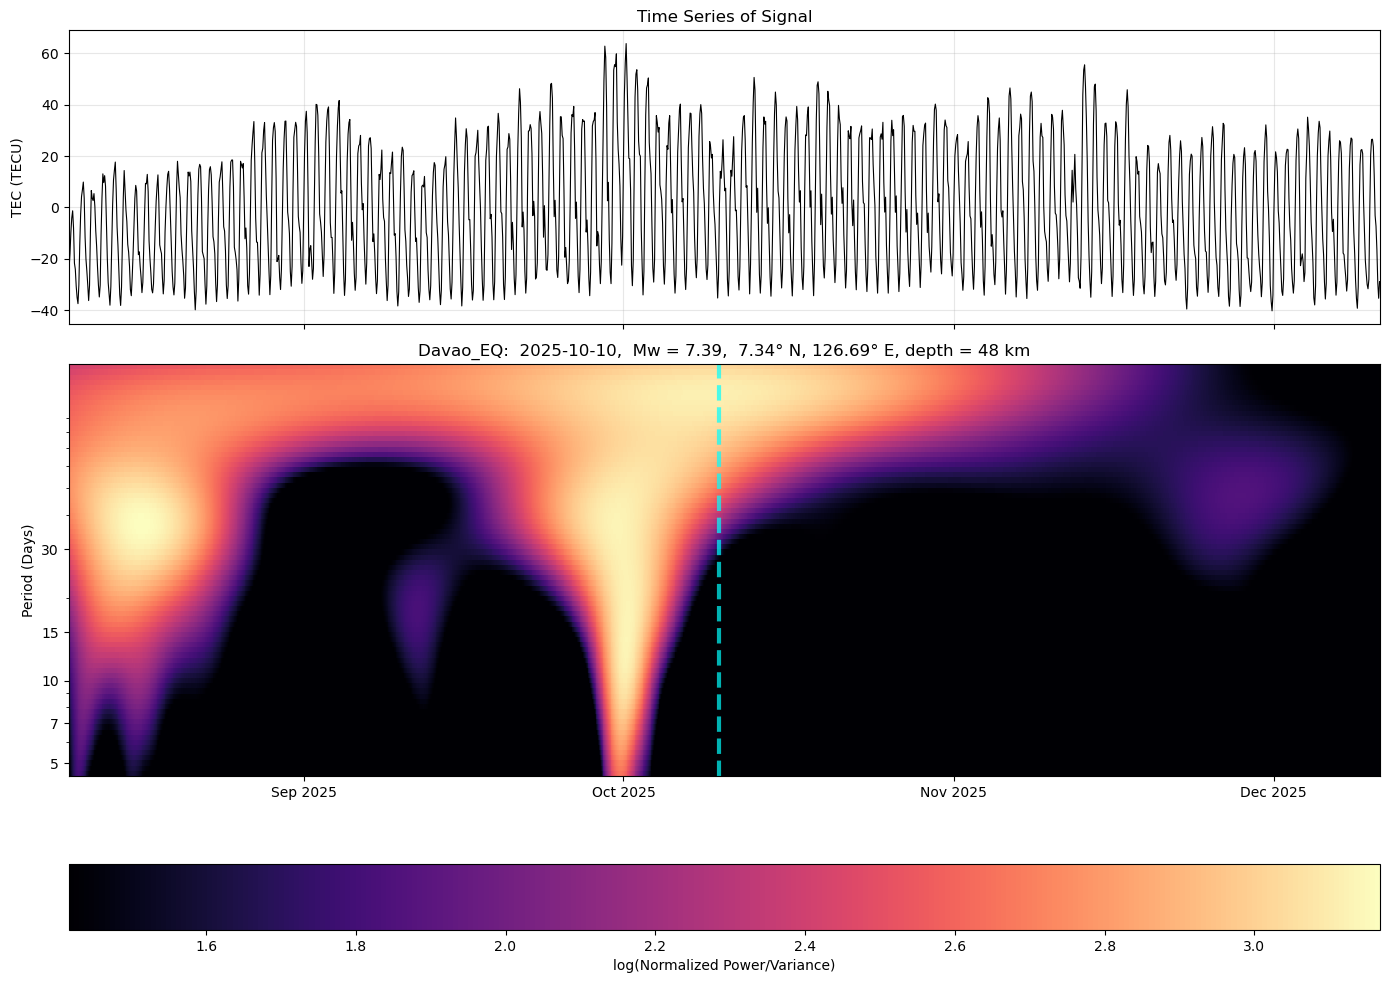

In [14]:
for i in range(10):
    ds_real = pd.read_csv(EQs[i,2]+"_point_2mo_anom.csv")

    time = pd.to_datetime(ds_real["time"])
    tec = ds_real["tec"]

    # calculate dt 
    # Subtracting two datetime64 objects gives a timedelta64.
    # Dividing by timedelta64(1, 'D') converts that exact duration into a fraction of a day.
    dt_days = float((time[1] - time[0]) / np.timedelta64(1, 'D'))
    
    # wavelet analysis
    # scales_era5 = np.arange(1, 30, 0.5)  # was linear scales
    # this gives approx log spaced scales
    scales_ion = np.geomspace(1, 30, num=80)
    w0 = 1.0  # Default Morlet parameter
    cwt_ion = cwt_scratch(tec, dt=dt_days, scales=scales_ion, w0=w0)

    # convert to plot periods
    # plotting function expects 'periods', not raw scales
    power_ion = np.abs(cwt_ion)**2
    fourier_factor = (4 * np.pi) / (w0 + np.sqrt(2 + w0**2))
    periods_ion = scales_ion * fourier_factor

    # make the plot 
    fig, ax_sig, ax_wav = plot_wavelet_spectrum(
        time=time, 
        periods=periods_ion, 
        power=power_ion, 
        title=EQs[i,2]+":  "+EQs[i,3]+",  Mw = "+EQs[i,4]+",  "+str(EQs[i,0])+"° N, "+str(EQs[i,1])+"° E, depth = "+EQs[i,5]+" km" , 
        v_signal=tec,
        tstitle="TEC (TECU)",
        ylabel="Period (Days)"
    )
    
    # You can still add your AEW band highlights to the returned ax_wav object!
    ax_wav.axvline(x=np.datetime64(EQs[i,3]), color='cyan', linestyle='--', alpha=0.7, lw=3)
    
    plt.tight_layout()
    plt.savefig("wavelet_"+str(i+1)+".png")
    plt.show()

## Analysis

Compare the strongest earthquake to the weakest.
Strongest: SurdelSur_EQ -> Strong anomaly more than a month prior
Weakest: NorCot_EQ -> Strong anomaly days before NorCot

Compare the deepest to the shallowest.
Deepest: Basilan_EQ -> Hardly any visible anomaly
Shallowest: NorCot_EQ, Masbate_EQ -> Strong anomaly days before NorCot, not much with Masbate

Perhaps compare fault boundaries.

## Premature Conclusions

The select earthquakes along the Philippines, albeit of similar magnitude, do not exhibit a reliable pattern of anomalous precursors in the ionosphere. Therefore, it does not seem possible to reliably predict earthquakes on a national scale based on ionospheric anomalies alone.

In [ ]:
## Recommendations

It may be more feasible to separately observe the behaviors of different fault systems. This may be more fruitful in predicting earthquakes than a national generalization.

It would also be better to consider anomalies due to geomagnetic storms, which affect the total electron content of the atmosphere, skewing results.